In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/NYC Accidents 2020.csv')
df.head(5)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2020-08-29,15:40:00,BRONX,10466.0,40.89210,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4342908,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
1,2020-08-29,21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Unspecified,NaN,NaN,NaN,4343555,Sedan,Sedan,NaN,NaN,NaN
2,2020-08-29,18:20:00,NaN,NaN,40.81650,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,NaN,NaN,...,NaN,NaN,NaN,NaN,4343142,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
3,2020-08-29,00:00:00,BRONX,10459.0,40.82472,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Unspecified,Unspecified,Unspecified,NaN,4343588,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN
4,2020-08-29,17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Unspecified,NaN,NaN,NaN,4342953,Sedan,Sedan,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     74881 non-null  object 
 1   CRASH TIME                     74881 non-null  object 
 2   BOROUGH                        49140 non-null  object 
 3   ZIP CODE                       49134 non-null  float64
 4   LATITUDE                       68935 non-null  float64
 5   LONGITUDE                      68935 non-null  float64
 6   LOCATION                       68935 non-null  object 
 7   ON STREET NAME                 55444 non-null  object 
 8   CROSS STREET NAME              35681 non-null  object 
 9   OFF STREET NAME                19437 non-null  object 
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64  
 11  NUMBER OF PERSONS KILLED       74881 non-null  int64  
 12  NUMBER OF PEDESTRIANS INJURED  74881 non-null 

In [ ]:
df.isnull().sum()

,0
CRASH DATE,0
CRASH TIME,0
BOROUGH,25741
ZIP CODE,25747
LATITUDE,5946
LONGITUDE,5946
LOCATION,5946
ON STREET NAME,19437
CROSS STREET NAME,39200
OFF STREET NAME,55444


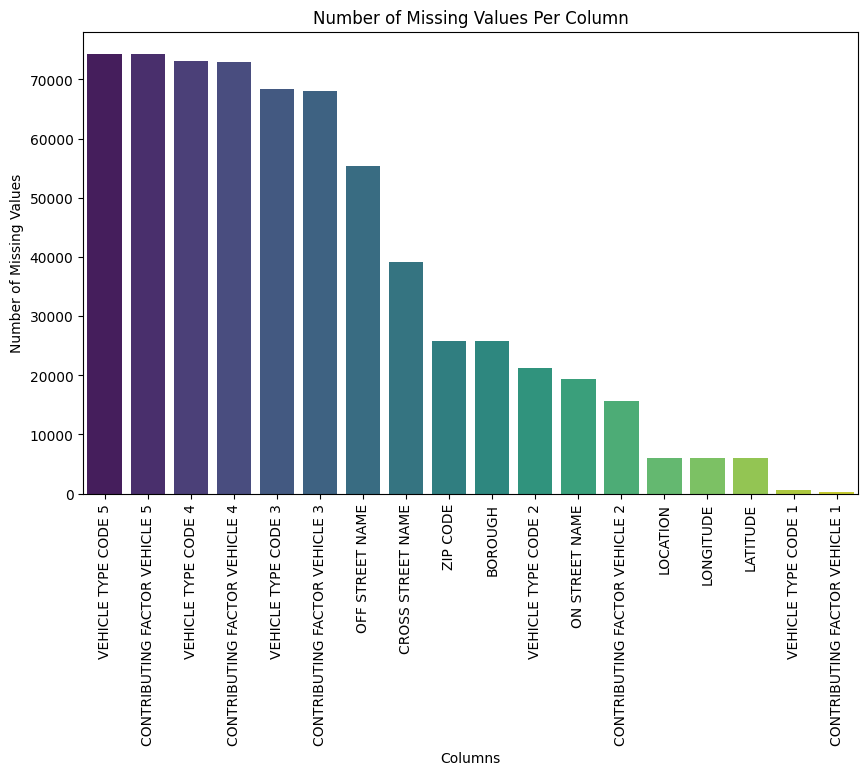

In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis', hue=missing_values.index, legend=False)
plt.xticks(rotation=90)
plt.title('Number of Missing Values Per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.show()

In [ ]:
print(df.duplicated().sum())

0


# **Tiền xử lý dữ liệu**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     74881 non-null  object 
 1   CRASH TIME                     74881 non-null  object 
 2   BOROUGH                        49140 non-null  object 
 3   ZIP CODE                       49134 non-null  float64
 4   LATITUDE                       68935 non-null  float64
 5   LONGITUDE                      68935 non-null  float64
 6   LOCATION                       68935 non-null  object 
 7   ON STREET NAME                 55444 non-null  object 
 8   CROSS STREET NAME              35681 non-null  object 
 9   OFF STREET NAME                19437 non-null  object 
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64  
 11  NUMBER OF PERSONS KILLED       74881 non-null  int64  
 12  NUMBER OF PEDESTRIANS INJURED  74881 non-null 

## Cột **CRASH DATE**

### Chuyển đổi kiểu dữ liệu thời gian

In [ ]:
df['CRASH DATE'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74881 entries, 0 to 74880
Series name: CRASH DATE
Non-Null Count  Dtype 
--------------  ----- 
74881 non-null  object
dtypes: object(1)
memory usage: 585.1+ KB


In [ ]:
# Chuyển đổi kiểu dữ liệu cho phù hợp
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['CRASH DATE'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74881 entries, 0 to 74880
Series name: CRASH DATE
Non-Null Count  Dtype         
--------------  -----         
74881 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 585.1 KB


In [ ]:
df['CRASH DATE'].value_counts().sort_index()

,count
CRASH DATE,
2020-01-01,336
2020-01-02,409
2020-01-03,452
2020-01-04,347
2020-01-05,286
...,...
2020-08-25,264
2020-08-26,280
2020-08-27,281


In [ ]:
df['CRASH DATE'].head(5)

,CRASH DATE
0,2020-08-29
1,2020-08-29
2,2020-08-29
3,2020-08-29
4,2020-08-29


In [ ]:
# Extract month from 'CRASH DATE'
df['CRASH MONTH'] = df['CRASH DATE'].dt.month

# Group by month and count accidents
monthly_accident_counts = df['CRASH MONTH'].value_counts().sort_index()

print("Accidents per month:")
print(monthly_accident_counts)

Accidents per month:
CRASH MONTH
1    14287
2    13684
3    11057
4     4116
5     6149
6     7616
7     9225
8     8747
Name: count, dtype: int64


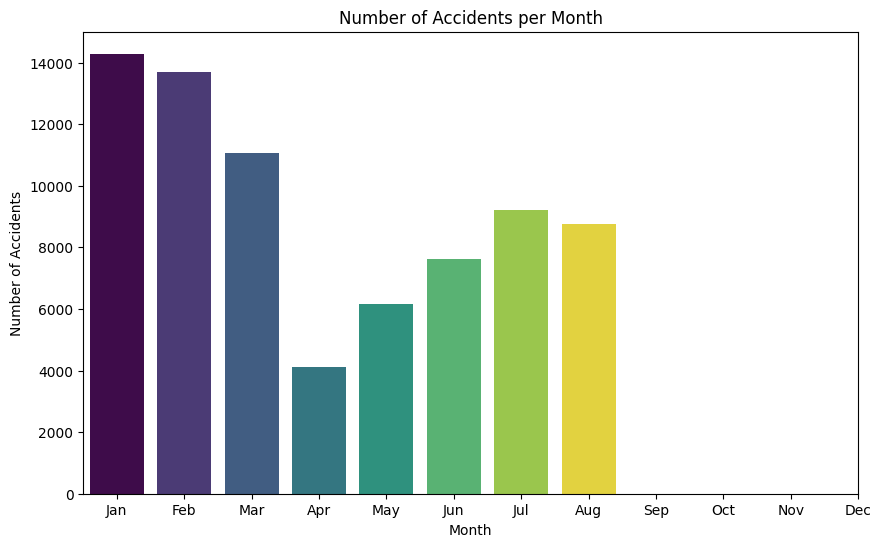

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_accident_counts.index, y=monthly_accident_counts.values, palette='viridis', hue=monthly_accident_counts.index, legend=False)
plt.title('Number of Accidents per Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

### Tạo thêm cột ngày, tháng, giờ

In [ ]:
df['Month'] = df['CRASH DATE'].dt.month
df['Hour'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M:%S', errors='coerce').dt.hour
df['DayOfWeek'] = df['CRASH DATE'].dt.day_name()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   CRASH DATE                     74881 non-null  datetime64[ns]
 1   CRASH TIME                     74881 non-null  object        
 2   BOROUGH                        49140 non-null  object        
 3   ZIP CODE                       49134 non-null  float64       
 4   LATITUDE                       68935 non-null  float64       
 5   LONGITUDE                      68935 non-null  float64       
 6   LOCATION                       68935 non-null  object        
 7   ON STREET NAME                 55444 non-null  object        
 8   CROSS STREET NAME              35681 non-null  object        
 9   OFF STREET NAME                19437 non-null  object        
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64         
 11  NUMBER OF PERSO

In [ ]:
df['Month'].value_counts().sort_index()

,count
Month,
1,14287
2,13684
3,11057
4,4116
5,6149
6,7616
7,9225
8,8747


#### Phân tích theo giờ

In [ ]:
df['Hour'].value_counts().sort_index()

,count
Hour,
0,2948
1,1474
2,1139
3,989
4,975
5,1178
6,1868
7,2463
8,3678


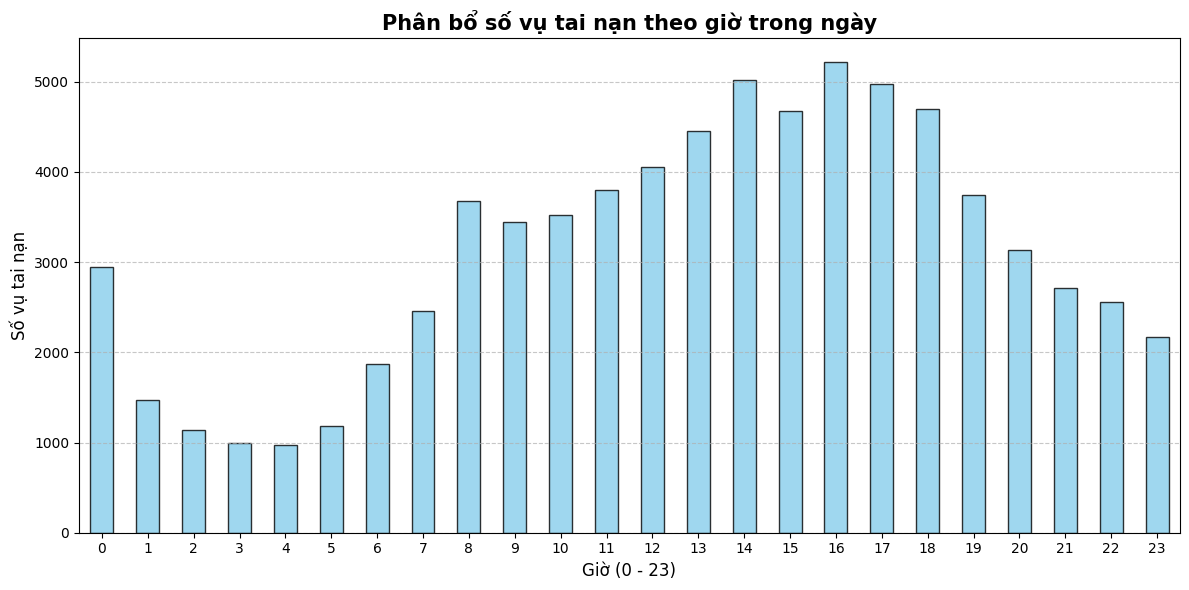

In [ ]:
# 1. Chuẩn bị dữ liệu
hourly_counts = df['Hour'].value_counts().sort_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)

# 3. Tinh chỉnh tiêu đề và nhãn
plt.title('Phân bổ số vụ tai nạn theo giờ trong ngày', fontsize=15, fontweight='bold')
plt.xlabel('Giờ (0 - 23)', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)

# 4. Thêm lưới ngang để dễ quan sát số liệu
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Xoay nhãn trục X để không bị chồng chéo (nếu cần)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Phân tích theo ngày tuần

In [ ]:
df['DayOfWeek'].value_counts().sort_index()

,count
DayOfWeek,
Friday,12271
Monday,10511
Saturday,10601
Sunday,9003
Thursday,11244
Tuesday,10613
Wednesday,10638


In [ ]:
df['DayOfWeek'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74881 entries, 0 to 74880
Series name: DayOfWeek
Non-Null Count  Dtype 
--------------  ----- 
74881 non-null  object
dtypes: object(1)
memory usage: 585.1+ KB


/tmp/ipykernel_565/3479025298.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


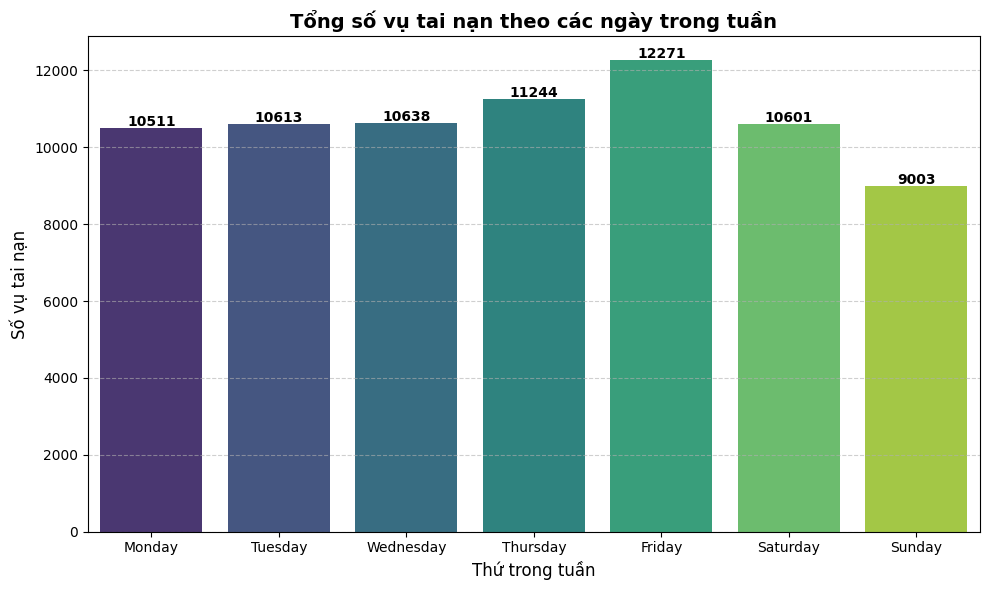

In [ ]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Nếu dữ liệu là Tiếng Việt, bạn hãy thay đổi danh sách này tương ứng:
# days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Tính toán số lượng vụ tai nạn theo từng thứ và sắp xếp theo thứ tự trên
day_counts = df['DayOfWeek'].value_counts().reindex(days_order)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')

# 4. Thêm các chi tiết bổ trợ
plt.title('Tổng số vụ tai nạn theo các ngày trong tuần', fontsize=14, fontweight='bold')
plt.xlabel('Thứ trong tuần', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị số liệu cụ thể trên đầu mỗi cột (tùy chọn)
for i, v in enumerate(day_counts.values):
    plt.text(i, v + 50, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Phân tích theo thời gian

/tmp/ipykernel_565/4232814724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='viridis')
/tmp/ipykernel_565/4232814724.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='magma')


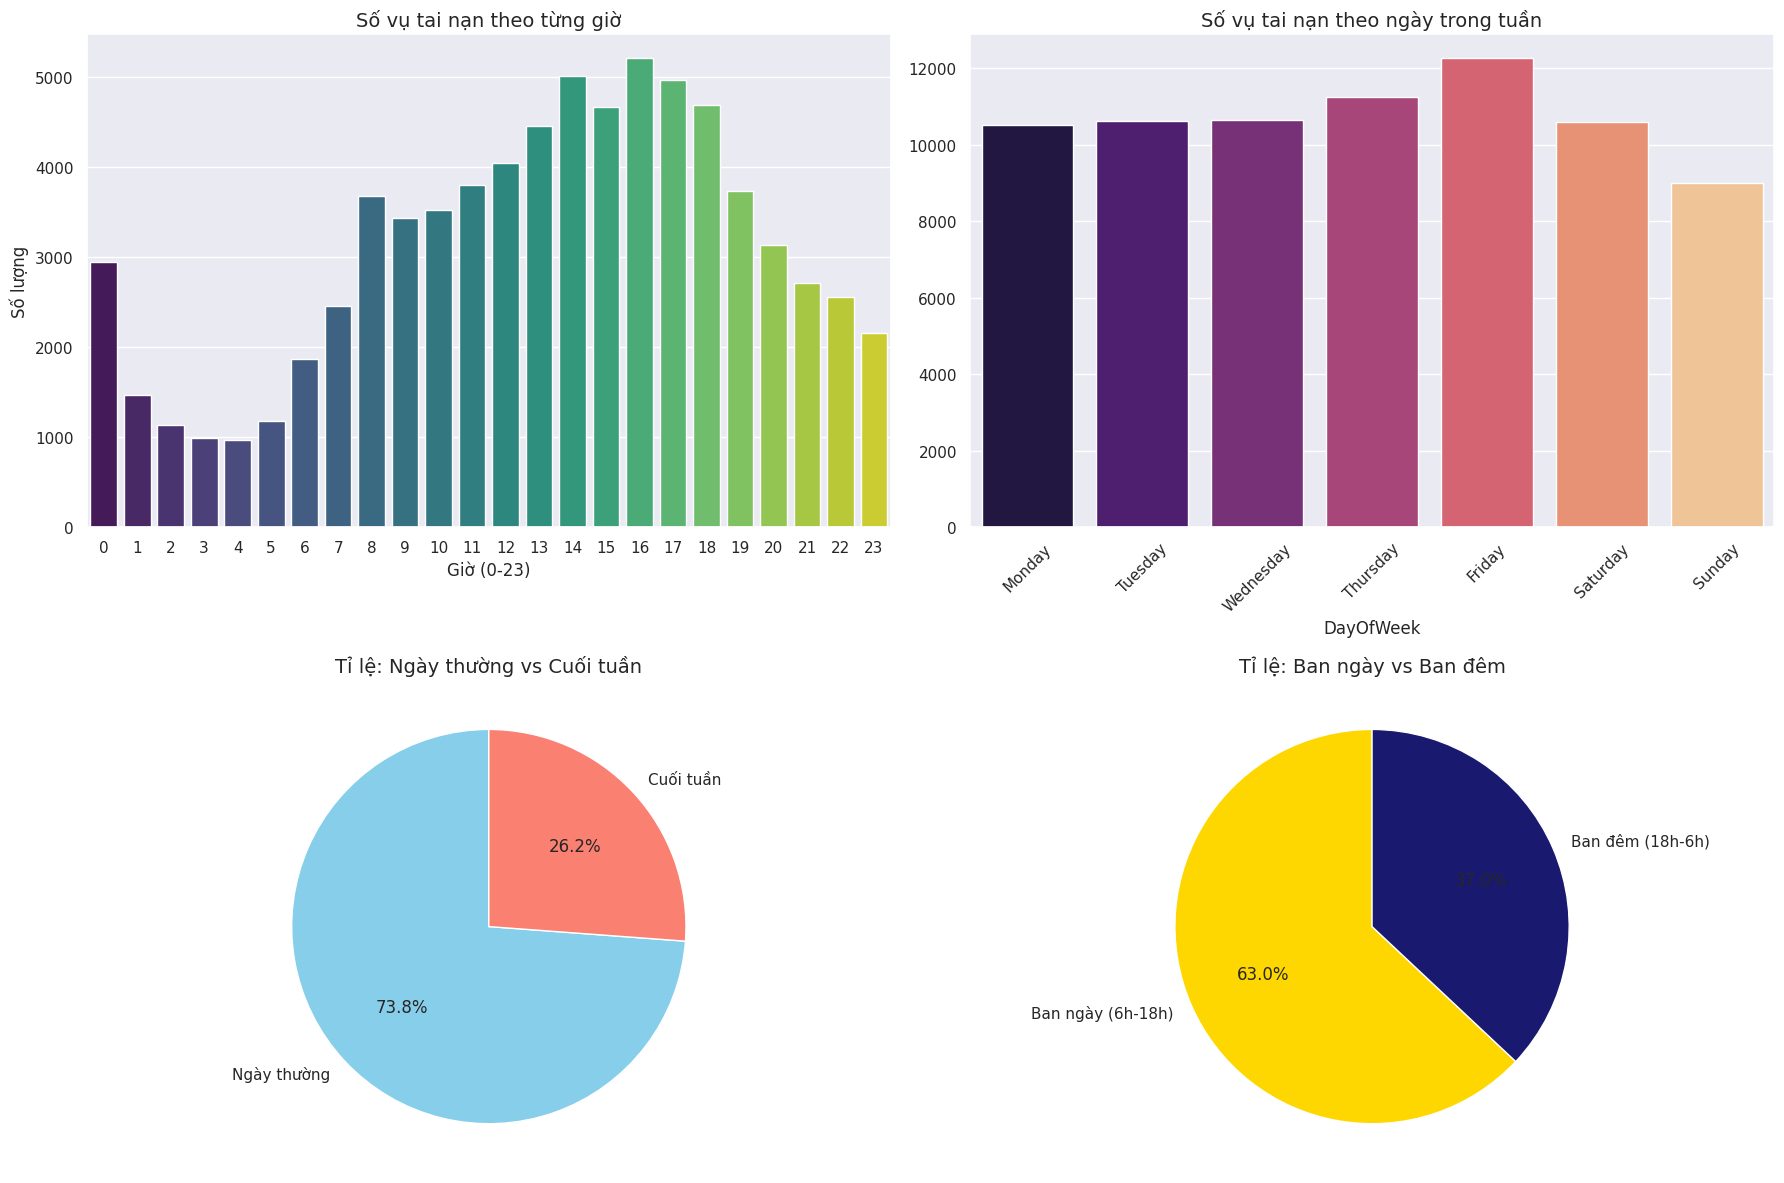

1. Giờ cao điểm nhất: 16h với 5219 vụ.
2. Ngày thường xảy ra tai nạn nhiều nhất: Friday.
3. Trung bình mỗi ngày thường có: 11055 vụ.
4. Trung bình mỗi ngày cuối tuần có: 9802 vụ.


In [ ]:
# Thiết lập phong cách cho biểu đồ
sns.set(style="darkgrid")
plt.figure(figsize=(18, 12))

# ---  GIỜ NÀO TRONG NGÀY TAI NẠN NHIỀU NHẤT? ---
plt.subplot(2, 2, 1)
hourly_counts = df['Hour'].value_counts().sort_index()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='viridis')
plt.title('Số vụ tai nạn theo từng giờ', fontsize=14)
plt.xlabel('Giờ (0-23)')
plt.ylabel('Số lượng')

# --- NGÀY NÀO TRONG TUẦN TAI NẠN NHIỀU NHẤT? ---
plt.subplot(2, 2, 2)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['DayOfWeek'].value_counts().reindex(days_order)
sns.barplot(x=day_counts.index, y=day_counts.values, palette='magma')
plt.title('Số vụ tai nạn theo ngày trong tuần', fontsize=14)
plt.xticks(rotation=45)

# --- SO SÁNH NGÀY THƯỜNG VS CUỐI TUẦN ---
plt.subplot(2, 2, 3)
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 'Cuối tuần' if x in ['Saturday', 'Sunday'] else 'Ngày thường')
weekend_counts = df['IsWeekend'].value_counts()
plt.pie(weekend_counts, labels=weekend_counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title('Tỉ lệ: Ngày thường vs Cuối tuần', fontsize=14)

# --- SO SÁNH BAN NGÀY VS BAN ĐÊM ---
# Quy ước: Ban ngày (6h - 18h), Ban đêm (18h - 6h sáng hôm sau)
plt.subplot(2, 2, 4)
df['DayNight'] = df['Hour'].apply(lambda x: 'Ban ngày (6h-18h)' if 6 <= x < 18 else 'Ban đêm (18h-6h)')
daynight_counts = df['DayNight'].value_counts()
plt.pie(daynight_counts, labels=daynight_counts.index, autopct='%1.1f%%', colors=['gold', 'midnightblue'], startangle=90)
plt.title('Tỉ lệ: Ban ngày vs Ban đêm', fontsize=14)

plt.tight_layout()
plt.show()


print(f"1. Giờ cao điểm nhất: {hourly_counts.idxmax()}h với {hourly_counts.max()} vụ.")
print(f"2. Ngày thường xảy ra tai nạn nhiều nhất: {day_counts.idxmax()}.")
print(f"3. Trung bình mỗi ngày thường có: {int(day_counts[:5].mean())} vụ.")
print(f"4. Trung bình mỗi ngày cuối tuần có: {int(day_counts[5:].mean())} vụ.")

In [ ]:
df['BOROUGH'].value_counts()

,count
BOROUGH,
BROOKLYN,16907
QUEENS,14017
BRONX,9417
MANHATTAN,7353
STATEN ISLAND,1446


Cột BOROUGH trong tập dữ liệu này đại diện cho tên các quận hành chính (boroughs) của thành phố New York, nơi vụ tai nạn xảy ra. New York City có 5 quận chính: Manhattan, Brooklyn, Queens, Bronx, và Staten Island.

In [ ]:
df['BOROUGH'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74881 entries, 0 to 74880
Series name: BOROUGH
Non-Null Count  Dtype 
--------------  ----- 
49140 non-null  object
dtypes: object(1)
memory usage: 585.1+ KB


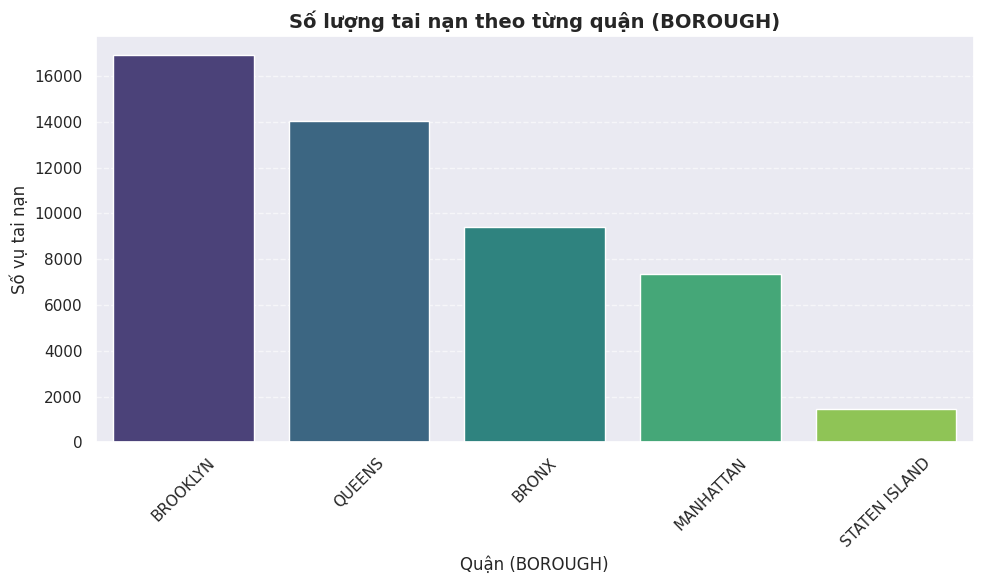

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df['BOROUGH'].value_counts().index, y=df['BOROUGH'].value_counts().values, palette='viridis', hue=df['BOROUGH'].value_counts().index, legend=False)
plt.title('Số lượng tai nạn theo từng quận (BOROUGH)', fontsize=14, fontweight='bold')
plt.xlabel('Quận (BOROUGH)', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
df_1 = df

In [ ]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   CRASH DATE                     74881 non-null  datetime64[ns]
 1   CRASH TIME                     74881 non-null  object        
 2   BOROUGH                        49140 non-null  object        
 3   ZIP CODE                       49134 non-null  float64       
 4   LATITUDE                       68935 non-null  float64       
 5   LONGITUDE                      68935 non-null  float64       
 6   LOCATION                       68935 non-null  object        
 7   ON STREET NAME                 55444 non-null  object        
 8   CROSS STREET NAME              35681 non-null  object        
 9   OFF STREET NAME                19437 non-null  object        
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64         
 11  NUMBER OF PERSO

In [ ]:
# Gán giá trị thiếu cho giá trị 'Unknown'
df_1['BOROUGH'] = df_1['BOROUGH'].fillna('Unknown')

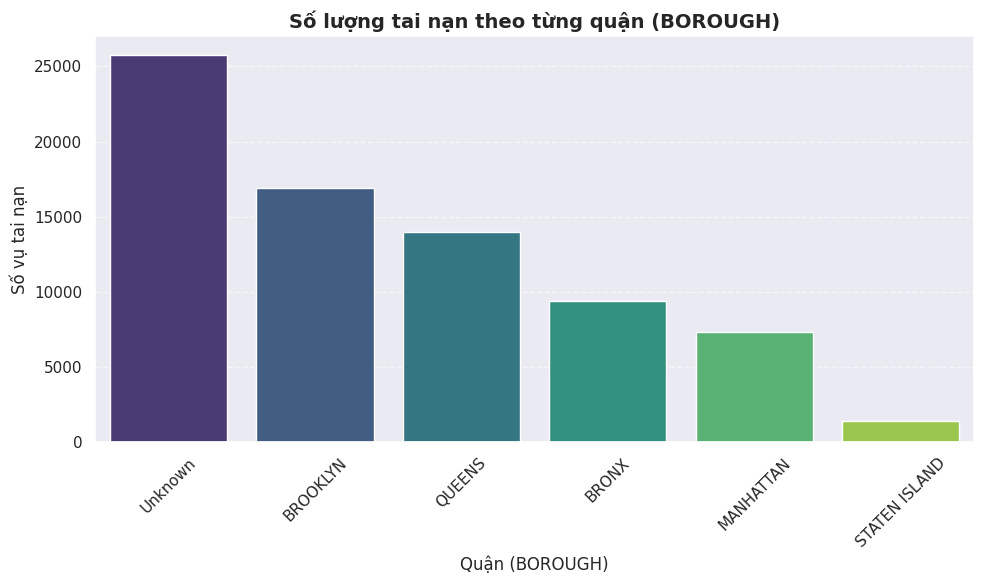

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_1['BOROUGH'].value_counts().index, y=df_1['BOROUGH'].value_counts().values, palette='viridis', hue=df['BOROUGH'].value_counts().index, legend=False)
plt.title('Số lượng tai nạn theo từng quận (BOROUGH)', fontsize=14, fontweight='bold')
plt.xlabel('Quận (BOROUGH)', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
borough_accident_percentage = df_1['BOROUGH'].value_counts(normalize=True) * 100
print("Tỷ lệ phần trăm số vụ tai nạn theo từng quận (BOROUGH):")
print(borough_accident_percentage)

Tỷ lệ phần trăm số vụ tai nạn theo từng quận (BOROUGH):
BOROUGH
Unknown          34.375876
BROOKLYN         22.578491
QUEENS           18.719034
BRONX            12.575954
MANHATTAN         9.819580
STATEN ISLAND     1.931064
Name: proportion, dtype: float64


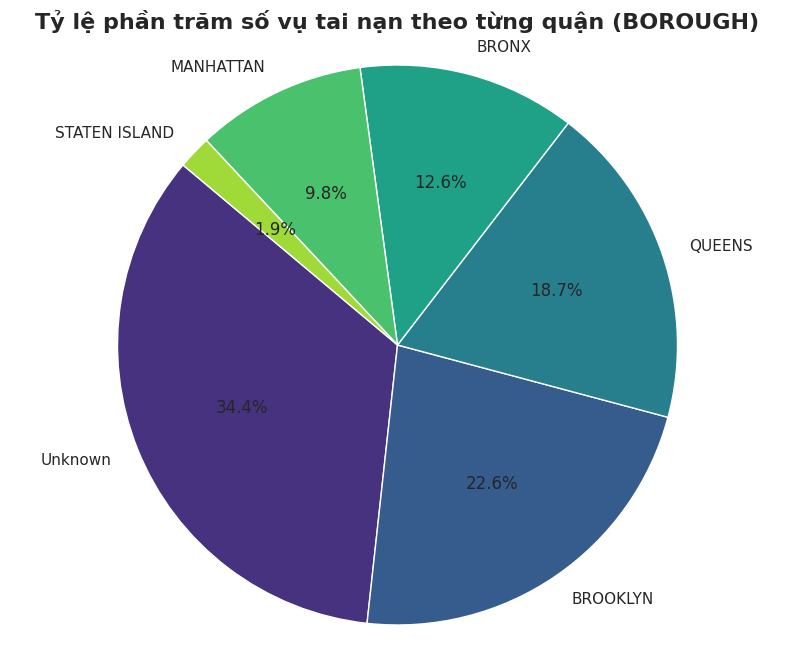

In [ ]:
plt.figure(figsize=(10, 8))
plt.pie(borough_accident_percentage, labels=borough_accident_percentage.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(borough_accident_percentage)))
plt.title('Tỷ lệ phần trăm số vụ tai nạn theo từng quận (BOROUGH)', fontsize=16, fontweight='bold')
plt.axis('equal') # Ensures that pie is drawn as a circle.
plt.show()

In [ ]:
df_1['ZIP CODE'].value_counts()

,count
ZIP CODE,
11207.0,1123
11236.0,936
11212.0,850
11203.0,809
11385.0,783
...,...
10112.0,1
10169.0,1
10123.0,1


In [ ]:
# Gán các giá trị thiếu bằng 0 (Unknow)
df_1['ZIP CODE'] = df_1['ZIP CODE'].fillna(0)

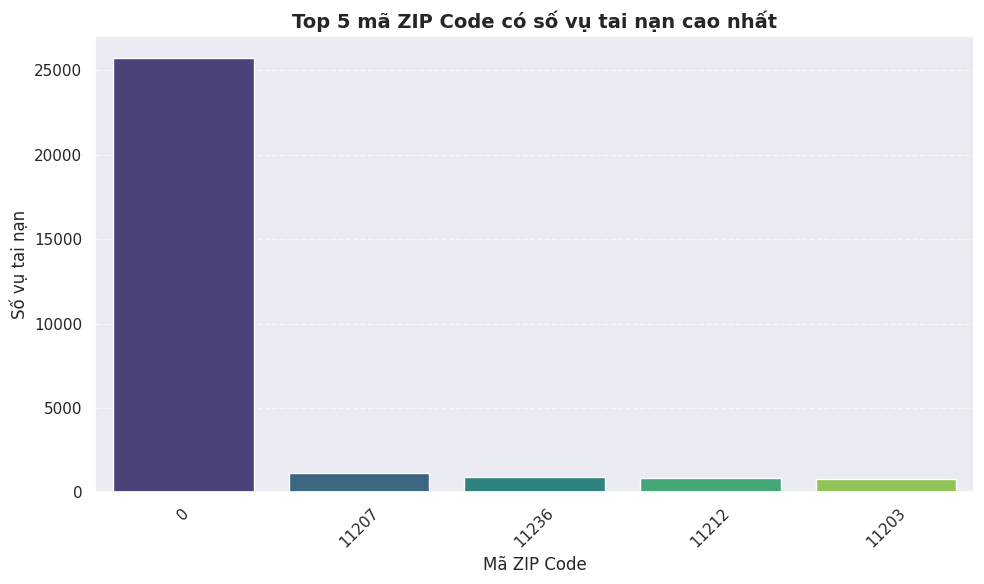

In [ ]:
top_5_zip_codes = df_1['ZIP CODE'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_zip_codes.index.astype(int).astype(str), y=top_5_zip_codes.values, palette='viridis', hue=top_5_zip_codes.index.astype(int).astype(str), legend=False)
plt.title('Top 5 mã ZIP Code có số vụ tai nạn cao nhất', fontsize=14, fontweight='bold')
plt.xlabel('Mã ZIP Code', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
cols_to_fill = ['ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME',
                'CONTRIBUTING FACTOR VEHICLE 1']
for col in cols_to_fill:
    df[col] = df[col].fillna('Unknown')

## Phân tích nạn nhân (Casualties Analysis)

In [ ]:
# 1. Tính tổng số người bị thương và tử vong
total_injured = df['NUMBER OF PERSONS INJURED'].sum()
total_killed = df['NUMBER OF PERSONS KILLED'].sum()

print(f"Tổng số người bị thương: {total_injured}")
print(f"Tổng số người tử vong: {total_killed}")
print(f"Tổng số nạn nhân (bị thương + tử vong): {total_injured + total_killed}")

Tổng số người bị thương: 27448
Tổng số người tử vong: 144
Tổng số nạn nhân (bị thương + tử vong): 27592


### Nhóm nào bị ảnh hưởng nhiều nhất?

In [ ]:
# 2. Tính số lượng người bị thương và tử vong cho từng nhóm
ped_injured = df['NUMBER OF PEDESTRIANS INJURED'].sum()
ped_killed = df['NUMBER OF PEDESTRIANS KILLED'].sum()

cyclist_injured = df['NUMBER OF CYCLIST INJURED'].sum()
cyclist_killed = df['NUMBER OF CYCLIST KILLED'].sum()

motorist_injured = df['NUMBER OF MOTORIST INJURED'].sum()
motorist_killed = df['NUMBER OF MOTORIST KILLED'].sum()

casualties_data = {
    'Nhóm': ['Người đi bộ', 'Người đi xe đạp', 'Người lái xe'],
    'Bị thương': [ped_injured, cyclist_injured, motorist_injured],
    'Tử vong': [ped_killed, cyclist_killed, motorist_killed]
}
casualties_df = pd.DataFrame(casualties_data)
casualties_df['Tổng nạn nhân'] = casualties_df['Bị thương'] + casualties_df['Tử vong']

print("Số liệu thương vong theo nhóm:")
display(casualties_df)

most_affected_injured = casualties_df.loc[casualties_df['Bị thương'].idxmax()]
most_affected_killed = casualties_df.loc[casualties_df['Tử vong'].idxmax()]
most_affected_total = casualties_df.loc[casualties_df['Tổng nạn nhân'].idxmax()]

print(f"\nNhóm có số người bị thương nhiều nhất: {most_affected_injured['Nhóm']} ({most_affected_injured['Bị thương']} người)")
print(f"Nhóm có số người tử vong nhiều nhất: {most_affected_killed['Nhóm']} ({most_affected_killed['Tử vong']} người)")
print(f"Nhóm có tổng số nạn nhân nhiều nhất: {most_affected_total['Nhóm']} ({most_affected_total['Tổng nạn nhân']} người)")

Số liệu thương vong theo nhóm:


,Nhóm,Bị thương,Tử vong,Tổng nạn nhân
0,Người đi bộ,4099,56,4155
1,Người đi xe đạp,3273,9,3282
2,Người lái xe,20076,79,20155



Nhóm có số người bị thương nhiều nhất: Người lái xe (20076 người)
Nhóm có số người tử vong nhiều nhất: Người lái xe (79 người)
Nhóm có tổng số nạn nhân nhiều nhất: Người lái xe (20155 người)


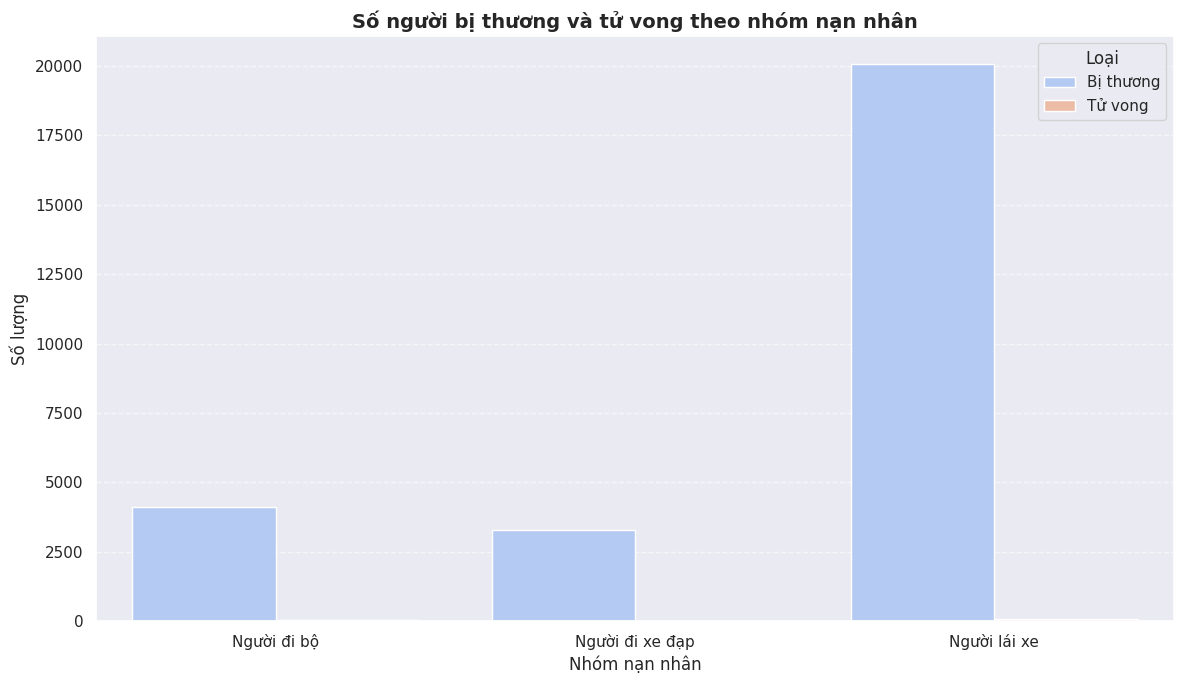

In [ ]:
# Vẽ biểu đồ cột so sánh số người bị thương và tử vong theo nhóm

casualties_df_melted = casualties_df.melt(id_vars='Nhóm', value_vars=['Bị thương', 'Tử vong'], var_name='Loại', value_name='Số lượng')

plt.figure(figsize=(12, 7))
sns.barplot(x='Nhóm', y='Số lượng', hue='Loại', data=casualties_df_melted, palette='coolwarm')
plt.title('Số người bị thương và tử vong theo nhóm nạn nhân', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm nạn nhân', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Tỷ lệ tử vong theo từng loại tai nạn

Tỷ lệ tử vong theo nhóm:


,Nhóm,Tử vong,Tổng số ảnh hưởng,Tỷ lệ tử vong
0,Người đi bộ,56,4155,1.347774
1,Người đi xe đạp,9,3282,0.274223
2,Người lái xe,79,20155,0.391962


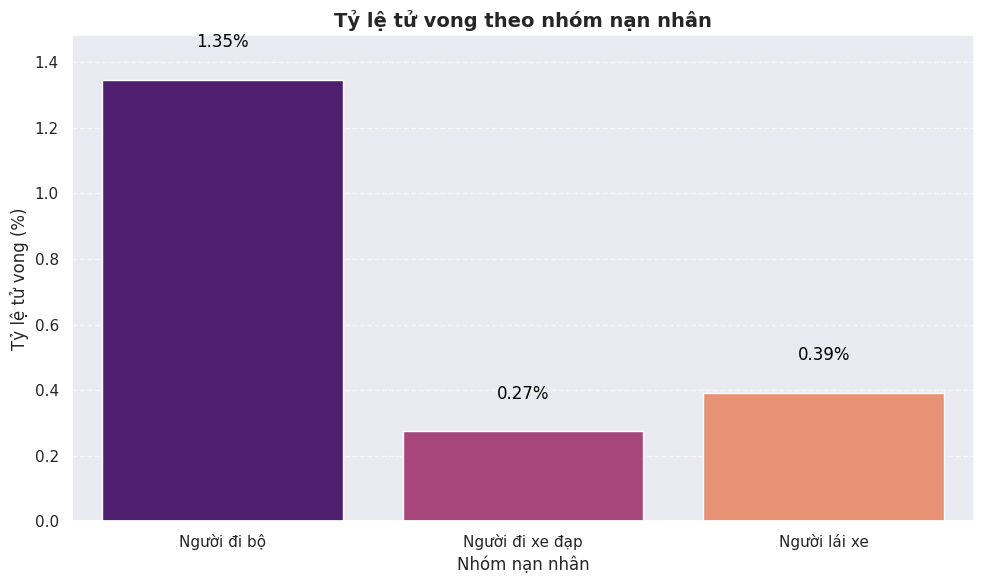

In [ ]:
# 3. Tính tỷ lệ tử vong
casualties_df['Tổng số ảnh hưởng'] = casualties_df['Bị thương'] + casualties_df['Tử vong']
casualties_df['Tỷ lệ tử vong'] = (casualties_df['Tử vong'] / casualties_df['Tổng số ảnh hưởng']) * 100
casualties_df = casualties_df.fillna(0) # Handle cases where Total Affected might be 0

print("Tỷ lệ tử vong theo nhóm:")
display(casualties_df[['Nhóm', 'Tử vong', 'Tổng số ảnh hưởng', 'Tỷ lệ tử vong']])

plt.figure(figsize=(10, 6))
sns.barplot(x='Nhóm', y='Tỷ lệ tử vong', data=casualties_df, palette='magma', hue='Nhóm', legend=False)
plt.title('Tỷ lệ tử vong theo nhóm nạn nhân', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm nạn nhân', fontsize=12)
plt.ylabel('Tỷ lệ tử vong (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, casualties_df['Tỷ lệ tử vong'].max() * 1.1) # Set y-limit for better visualization

# Display percentages on bars
for index, row in casualties_df.iterrows():
    plt.text(index, row['Tỷ lệ tử vong'] + 0.1, f"{row['Tỷ lệ tử vong']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

## Phân tích các yếu tố gây tai nạn (Contributing Factors Analysis)

In [ ]:
# 1. Xem xét các giá trị duy nhất và tần suất của 'CONTRIBUTING FACTOR VEHICLE 1'
contributing_factors = df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

print("Các yếu tố gây tai nạn chính (CONTRIBUTING FACTOR VEHICLE 1):")
display(contributing_factors.head(10)) # Hiển thị 10 yếu tố hàng đầu

Các yếu tố gây tai nạn chính (CONTRIBUTING FACTOR VEHICLE 1):


,count
CONTRIBUTING FACTOR VEHICLE 1,
Unspecified,19471
Driver Inattention/Distraction,19123
Following Too Closely,5202
Failure to Yield Right-of-Way,4815
Passing or Lane Usage Improper,2840
Backing Unsafely,2829
Passing Too Closely,2687
Other Vehicular,2233
Unsafe Speed,2015


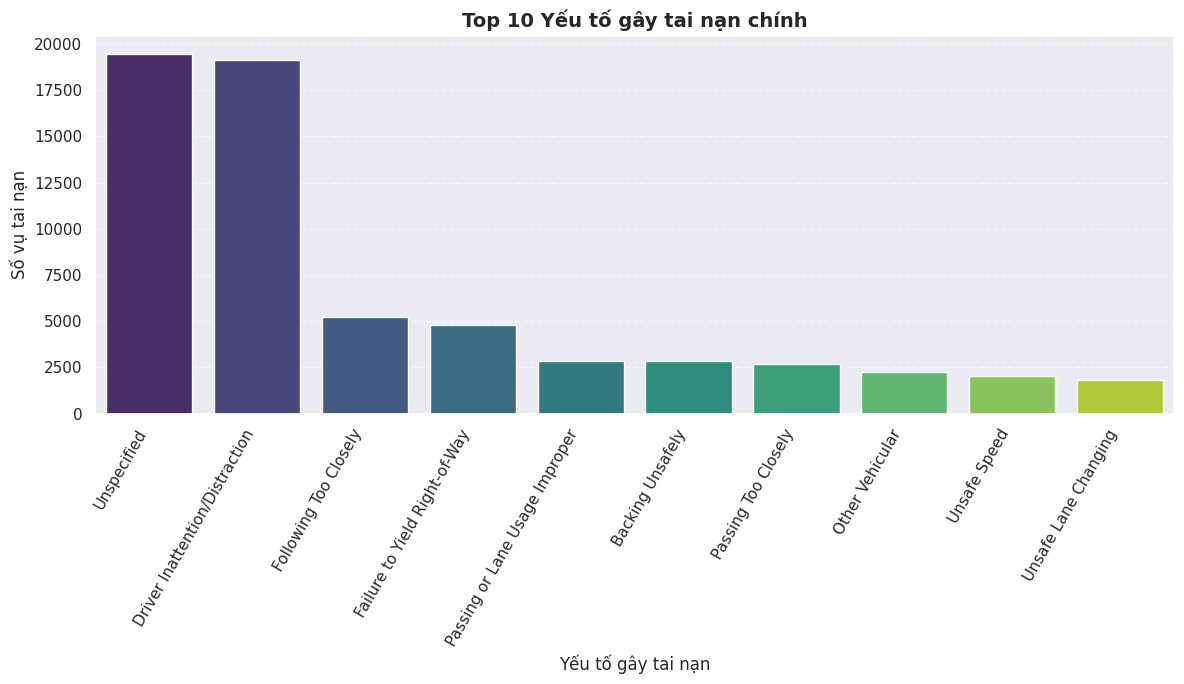

In [ ]:
# 2. Trực quan hóa 10 yếu tố gây tai nạn hàng đầu
plt.figure(figsize=(12, 7))
sns.barplot(x=contributing_factors.head(10).index, y=contributing_factors.head(10).values, palette='viridis', hue=contributing_factors.head(10).index, legend=False)
plt.title('Top 10 Yếu tố gây tai nạn chính', fontsize=14, fontweight='bold')
plt.xlabel('Yếu tố gây tai nạn', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Phân tích loại phương tiện liên quan (Vehicle Type Analysis)

In [ ]:
# 1. Xem xét các giá trị duy nhất và tần suất của 'VEHICLE TYPE CODE 1'
vehicle_types = df['VEHICLE TYPE CODE 1'].value_counts()

print("Các loại phương tiện chính liên quan đến tai nạn (VEHICLE TYPE CODE 1):")
display(vehicle_types.head(10)) # Hiển thị 10 loại phương tiện hàng đầu

Các loại phương tiện chính liên quan đến tai nạn (VEHICLE TYPE CODE 1):


,count
VEHICLE TYPE CODE 1,
Sedan,34349
Station Wagon/Sport Utility Vehicle,27541
Taxi,2768
Pick-up Truck,1882
Box Truck,1417
Bus,950
Bike,882
Tractor Truck Diesel,587
Motorcycle,518


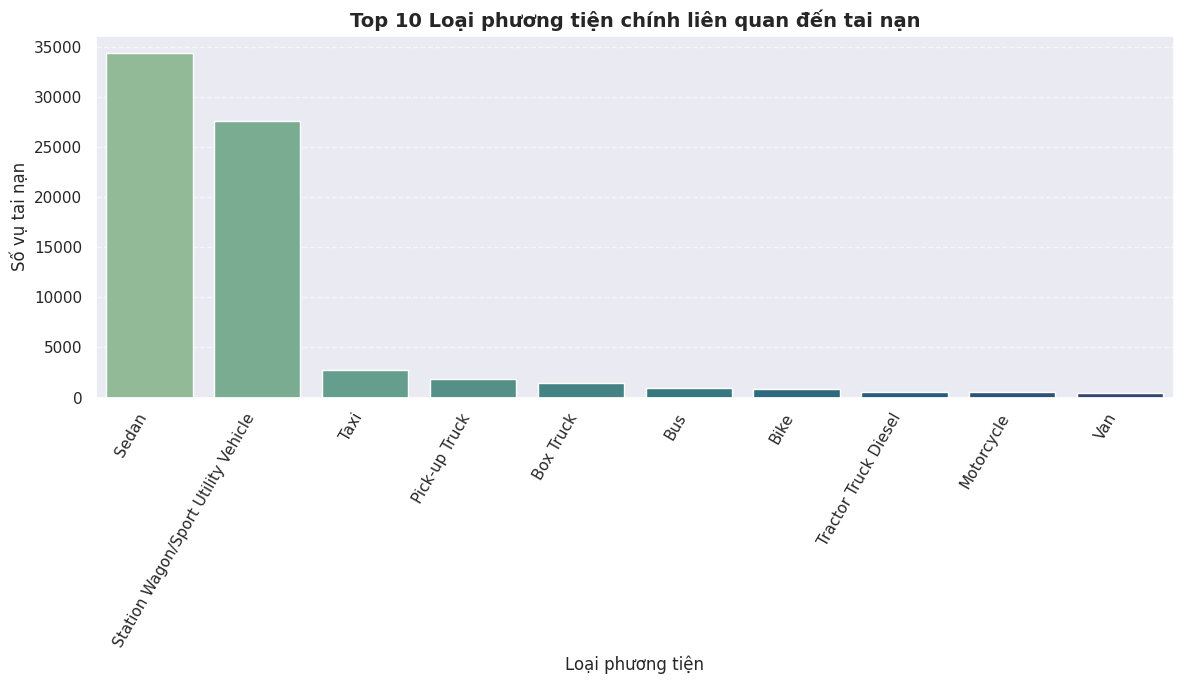

In [ ]:
# 2. Trực quan hóa 10 loại phương tiện hàng đầu
plt.figure(figsize=(12, 7))
sns.barplot(x=vehicle_types.head(10).index, y=vehicle_types.head(10).values, palette='crest', hue=vehicle_types.head(10).index, legend=False)
plt.title('Top 10 Loại phương tiện chính liên quan đến tai nạn', fontsize=14, fontweight='bold')
plt.xlabel('Loại phương tiện', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Phân tích kết hợp (Correlation / Relationship)

### 1. Nguyên nhân nào liên quan mạnh đến tai nạn nghiêm trọng?

Các yếu tố gây tai nạn hàng đầu theo tổng số nạn nhân:


,TOTAL_CASUALTIES
CONTRIBUTING FACTOR VEHICLE 1,
Driver Inattention/Distraction,7378
Unspecified,5329
Failure to Yield Right-of-Way,2814
Following Too Closely,2173
Unsafe Speed,1430
Traffic Control Disregarded,1179
Other Vehicular,752
Passing or Lane Usage Improper,691
Unsafe Lane Changing,544


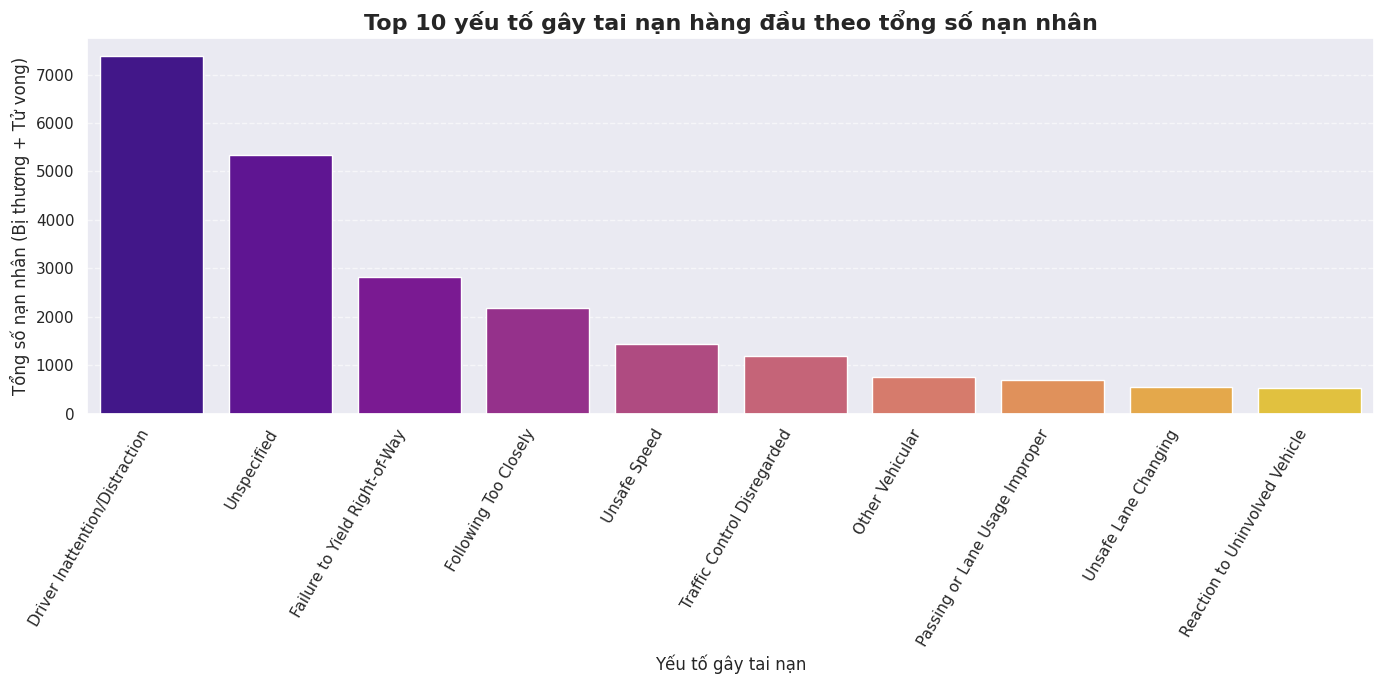

In [ ]:
# Bước 1: Định nghĩa mức độ nghiêm trọng của tai nạn
df['TOTAL_CASUALTIES'] = df['NUMBER OF PERSONS INJURED'] + df['NUMBER OF PERSONS KILLED']

# Bước 2: Phân tích các yếu tố gây tai nạn liên quan đến mức độ nghiêm trọng
# Group by contributing factor and calculate the sum of casualties
severity_by_factor = df.groupby('CONTRIBUTING FACTOR VEHICLE 1')['TOTAL_CASUALTIES'].sum().sort_values(ascending=False)

print("Các yếu tố gây tai nạn hàng đầu theo tổng số nạn nhân:")
display(severity_by_factor.head(10))

# Trực quan hóa
plt.figure(figsize=(14, 7))
sns.barplot(x=severity_by_factor.head(10).index, y=severity_by_factor.head(10).values, palette='plasma', hue=severity_by_factor.head(10).index, legend=False)
plt.title('Top 10 yếu tố gây tai nạn hàng đầu theo tổng số nạn nhân', fontsize=16, fontweight='bold')
plt.xlabel('Yếu tố gây tai nạn', fontsize=12)
plt.ylabel('Tổng số nạn nhân (Bị thương + Tử vong)', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 2. Mối quan hệ giữa các yếu tố gây tai nạn và quận?

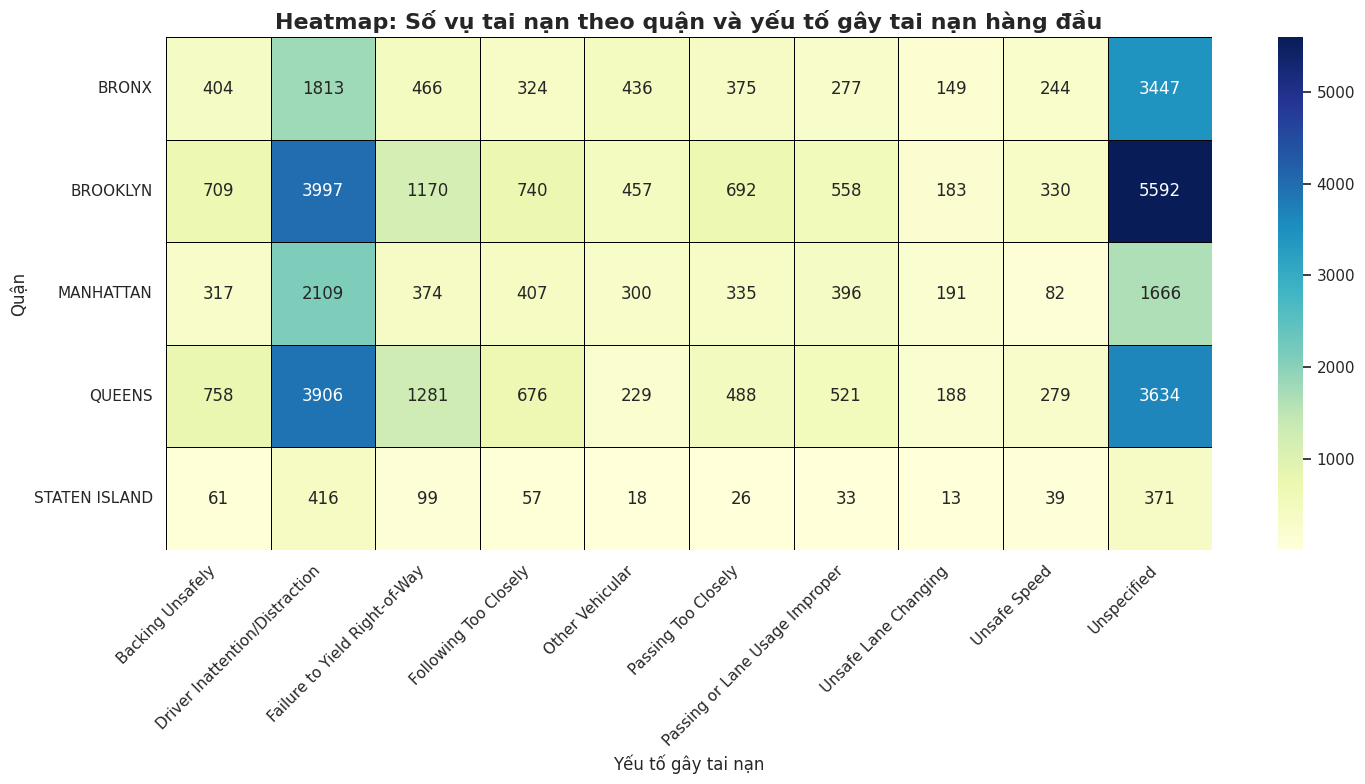

In [ ]:
# Lấy ra 10 yếu tố gây tai nạn hàng đầu (trừ 'Unknown')
top_factors = df[df['CONTRIBUTING FACTOR VEHICLE 1'] != 'Unknown']['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(10).index.tolist()

# Lọc DataFrame để chỉ giữ lại các quận và các yếu tố hàng đầu này
df_filtered = df[(df['BOROUGH'] != 'Unknown') & (df['CONTRIBUTING FACTOR VEHICLE 1'].isin(top_factors))]

# Tạo bảng tổng hợp số vụ tai nạn theo quận và yếu tố gây tai nạn
heatmap_data = df_filtered.pivot_table(index='BOROUGH', columns='CONTRIBUTING FACTOR VEHICLE 1', aggfunc='size', fill_value=0)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, linecolor='black')
plt.title('Heatmap: Số vụ tai nạn theo quận và yếu tố gây tai nạn hàng đầu', fontsize=16, fontweight='bold')
plt.xlabel('Yếu tố gây tai nạn', fontsize=12)
plt.ylabel('Quận', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Phân tích bất thường (Anomaly Detection)

### 1. Có ngày nào số vụ tai nạn tăng đột biến không?

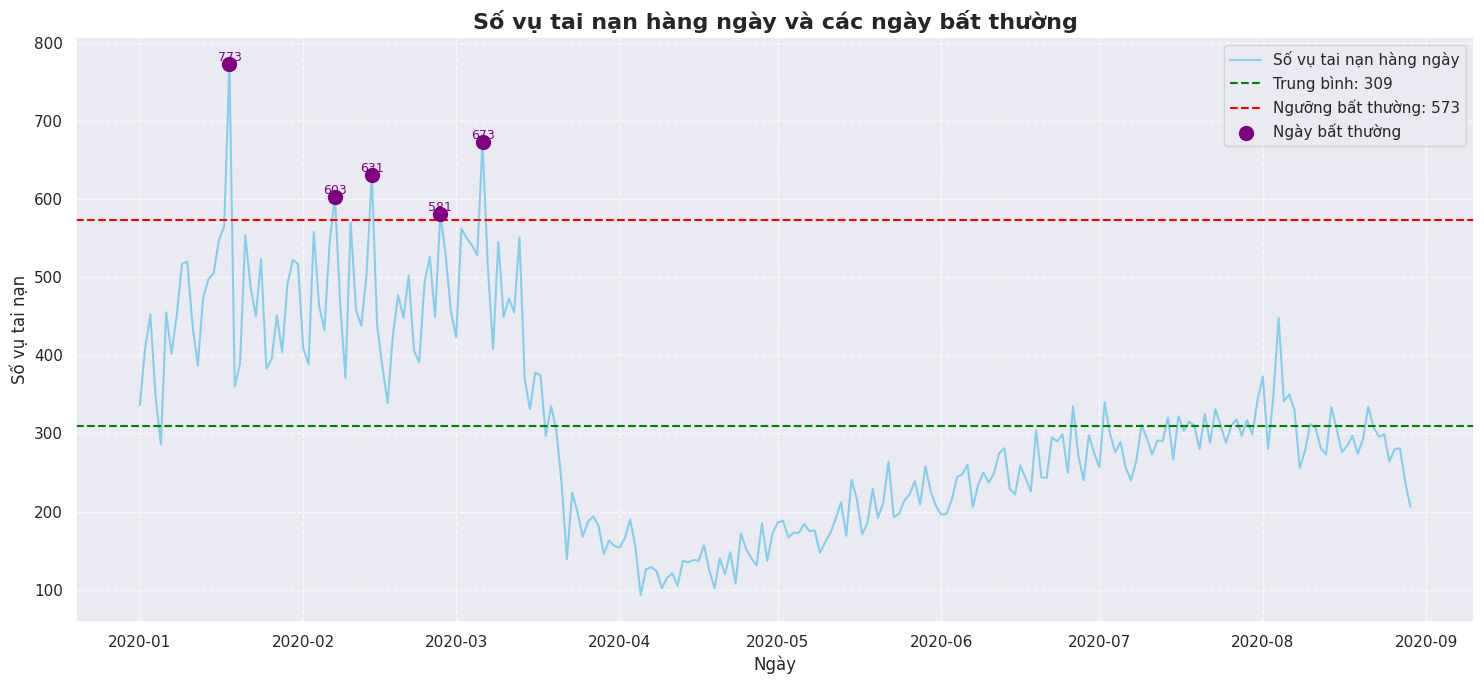


Trung bình số vụ tai nạn hàng ngày: 309
Ngưỡng bất thường (Trung bình + 2*StdDev): 573

Các ngày có số vụ tai nạn tăng đột biến:


,count
CRASH DATE,
2020-01-18,773
2020-02-07,603
2020-02-14,631
2020-02-27,581
2020-03-06,673


In [ ]:
# Đếm số vụ tai nạn mỗi ngày
daily_accidents = df['CRASH DATE'].value_counts().sort_index()

# Tính toán ngưỡng cho các điểm bất thường
mean_daily_accidents = daily_accidents.mean()
std_daily_accidents = daily_accidents.std()

# Định nghĩa ngưỡng: ví dụ, lớn hơn 2 độ lệch chuẩn so với trung bình
anomaly_threshold = mean_daily_accidents + (2 * std_daily_accidents)

# Xác định các ngày bất thường
anomaly_days = daily_accidents[daily_accidents > anomaly_threshold]

plt.figure(figsize=(15, 7))
plt.plot(daily_accidents.index, daily_accidents.values, label='Số vụ tai nạn hàng ngày', color='skyblue')
plt.axhline(mean_daily_accidents, color='green', linestyle='--', label=f'Trung bình: {mean_daily_accidents:.0f}')
plt.axhline(anomaly_threshold, color='red', linestyle='--', label=f'Ngưỡng bất thường: {anomaly_threshold:.0f}')

# Đánh dấu các ngày bất thường trên biểu đồ
if not anomaly_days.empty:
    plt.scatter(anomaly_days.index, anomaly_days.values, color='purple', s=100, zorder=5, label='Ngày bất thường')
    for day, count in anomaly_days.items():
        plt.text(day, count, f'{count}', fontsize=9, ha='center', va='bottom', color='purple')

plt.title('Số vụ tai nạn hàng ngày và các ngày bất thường', fontsize=16, fontweight='bold')
plt.xlabel('Ngày', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nTrung bình số vụ tai nạn hàng ngày: {mean_daily_accidents:.0f}")
print(f"Ngưỡng bất thường (Trung bình + 2*StdDev): {anomaly_threshold:.0f}")

if not anomaly_days.empty:
    print("\nCác ngày có số vụ tai nạn tăng đột biến:")
    display(anomaly_days)
else:
    print("\nKhông có ngày nào có số vụ tai nạn tăng đột biến đáng kể (vượt quá 2 độ lệch chuẩn).")

### 2. Có khu vực nào bất thường không?

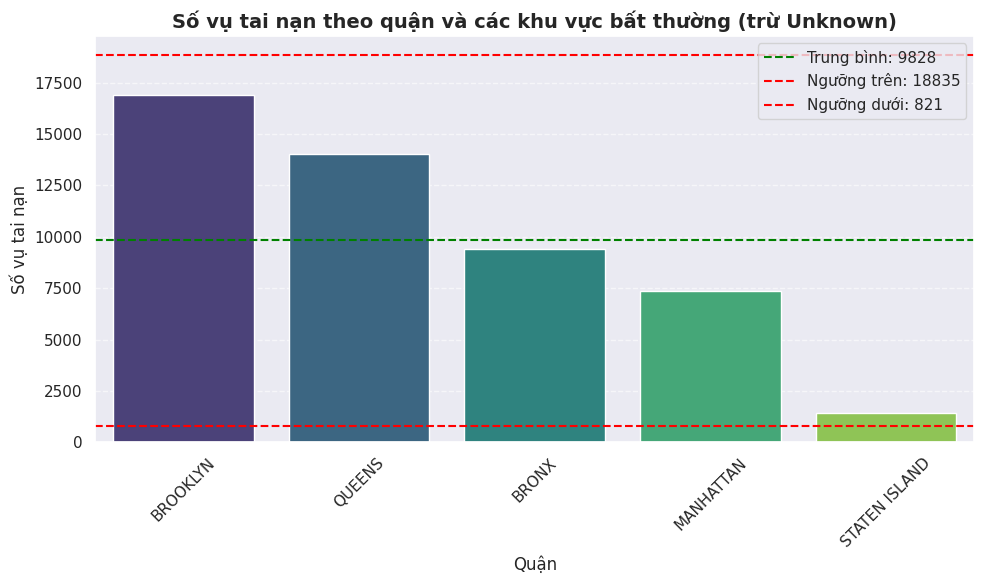


Trung bình số vụ tai nạn mỗi quận: 9828
Ngưỡng bất thường trên (Trung bình + 1.5*StdDev): 18835
Ngưỡng bất thường dưới (Trung bình - 1.5*StdDev): 821

Không có quận nào có số vụ tai nạn cao bất thường.

Không có quận nào có số vụ tai nạn thấp bất thường.


In [ ]:
# Đếm số vụ tai nạn theo quận (trừ 'Unknown')
borough_accidents = df[df['BOROUGH'] != 'Unknown']['BOROUGH'].value_counts()

# Tính toán ngưỡng cho các điểm bất thường
mean_borough_accidents = borough_accidents.mean()
std_borough_accidents = borough_accidents.std()

# Định nghĩa ngưỡng: ví dụ, lớn hơn 1.5 độ lệch chuẩn so với trung bình
anomaly_threshold_upper = mean_borough_accidents + (1.5 * std_borough_accidents)
anomaly_threshold_lower = mean_borough_accidents - (1.5 * std_borough_accidents)

# Xác định các quận bất thường
anomaly_boroughs_high = borough_accidents[borough_accidents > anomaly_threshold_upper]
anomaly_boroughs_low = borough_accidents[borough_accidents < anomaly_threshold_lower]

plt.figure(figsize=(10, 6))
sns.barplot(x=borough_accidents.index, y=borough_accidents.values, palette='viridis', hue=borough_accidents.index, legend=False)
plt.axhline(mean_borough_accidents, color='green', linestyle='--', label=f'Trung bình: {mean_borough_accidents:.0f}')
plt.axhline(anomaly_threshold_upper, color='red', linestyle='--', label=f'Ngưỡng trên: {anomaly_threshold_upper:.0f}')
plt.axhline(anomaly_threshold_lower, color='red', linestyle='--', label=f'Ngưỡng dưới: {anomaly_threshold_lower:.0f}')

# Đánh dấu các quận bất thường
if not anomaly_boroughs_high.empty:
    plt.scatter(anomaly_boroughs_high.index, anomaly_boroughs_high.values, color='purple', s=150, zorder=5, label='Quận bất thường (cao)')
    for borough, count in anomaly_boroughs_high.items():
        plt.text(borough, count, f'{count}', fontsize=9, ha='center', va='bottom', color='purple')

if not anomaly_boroughs_low.empty:
    plt.scatter(anomaly_boroughs_low.index, anomaly_boroughs_low.values, color='orange', s=150, zorder=5, label='Quận bất thường (thấp)')
    for borough, count in anomaly_boroughs_low.items():
        plt.text(borough, count, f'{count}', fontsize=9, ha='center', va='top', color='orange')

plt.title('Số vụ tai nạn theo quận và các khu vực bất thường (trừ Unknown)', fontsize=14, fontweight='bold')
plt.xlabel('Quận', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\nTrung bình số vụ tai nạn mỗi quận: {mean_borough_accidents:.0f}")
print(f"Ngưỡng bất thường trên (Trung bình + 1.5*StdDev): {anomaly_threshold_upper:.0f}")
print(f"Ngưỡng bất thường dưới (Trung bình - 1.5*StdDev): {anomaly_threshold_lower:.0f}")

if not anomaly_boroughs_high.empty:
    print("\nCác quận có số vụ tai nạn cao bất thường:")
    display(anomaly_boroughs_high)
else:
    print("\nKhông có quận nào có số vụ tai nạn cao bất thường.")

if not anomaly_boroughs_low.empty:
    print("\nCác quận có số vụ tai nạn thấp bất thường:")
    display(anomaly_boroughs_low)
else:
    print("\nKhông có quận nào có số vụ tai nạn thấp bất thường.")